# 03 · 단어 동시출현 네트워크

같은 기사에 함께 등장한 단어쌍(문서 단위 동시출현)으로 네트워크를 구성하고,
중심성으로 핵심어를 파악한다.

무거운 로직은 `src/network.py`에 있고, 여기서는 import해서 분석/시각화만 한다.

In [1]:
# 셋업
import sys; sys.path.append("..")

import matplotlib.pyplot as plt

import config
from src import preprocess as pp
from src import network as nw

config.set_korean_font()

df = pp.load_processed("news_tokenized")
token_lists = df["nouns"].tolist()
print("문서 수:", len(token_lists))

문서 수: 20079


## 1. 네트워크 구성

빈도 상위 50개 단어를 노드로 두고, 동시출현 300회 이상인 쌍만 엣지로 연결한다.
(임계값 `min_cooc`을 낮추면 더 조밀, 높이면 더 성긴 네트워크가 된다.)

In [2]:
G = nw.build_network(token_lists, top_n=50, min_cooc=300)
print("노드 수:", G.number_of_nodes())
print("엣지 수:", G.number_of_edges())

노드 수: 49
엣지 수: 294


## 2. 중심성 분석

연결(degree)·매개(betweenness)·고유벡터(eigenvector) 중심성으로 네트워크의 허브 단어를 찾는다.

In [3]:
cent = nw.centrality(G)
cent.to_csv(config.TABLE_DIR / "03_centrality.csv", index=False, encoding="utf-8-sig")

print("=== 연결 중심성 Top 10 ===")
print(cent.head(10).to_string(index=False))
print("\n=== 매개 중심성 Top 10 ===")
print(cent.sort_values("betweenness", ascending=False).head(10).to_string(index=False))

=== 연결 중심성 Top 10 ===
node  degree  betweenness  eigenvector  freq
  취약  0.8333       0.0687       0.4050  6444
  복지  0.8125       0.1334       0.3208  8404
  계층  0.8125       0.1259       0.4001  6276
  가구  0.7083       0.0337       0.3293  7209
독거노인  0.6458       0.0665       0.3277  5210
  예방  0.4583       0.0629       0.1604  3372
  안전  0.3958       0.0598       0.1320  3344
 고독사  0.3958       0.0301       0.1535  4137
  센터  0.3958       0.0408       0.1716  3847
  이웃  0.3750       0.0390       0.1629  3212

=== 매개 중심성 Top 10 ===
node  degree  betweenness  eigenvector  freq
  복지  0.8125       0.1334       0.3208  8404
  계층  0.8125       0.1259       0.4001  6276
  취약  0.8333       0.0687       0.4050  6444
독거노인  0.6458       0.0665       0.3277  5210
  예방  0.4583       0.0629       0.1604  3372
  안전  0.3958       0.0598       0.1320  3344
  노인  0.2708       0.0426       0.0934  4471
  센터  0.3958       0.0408       0.1716  3847
  이웃  0.3750       0.0390       0.1629  3212
  가구  0.70

## 3. 네트워크 시각화

노드 크기 = 단어 빈도, 엣지 굵기 = 동시출현 빈도.

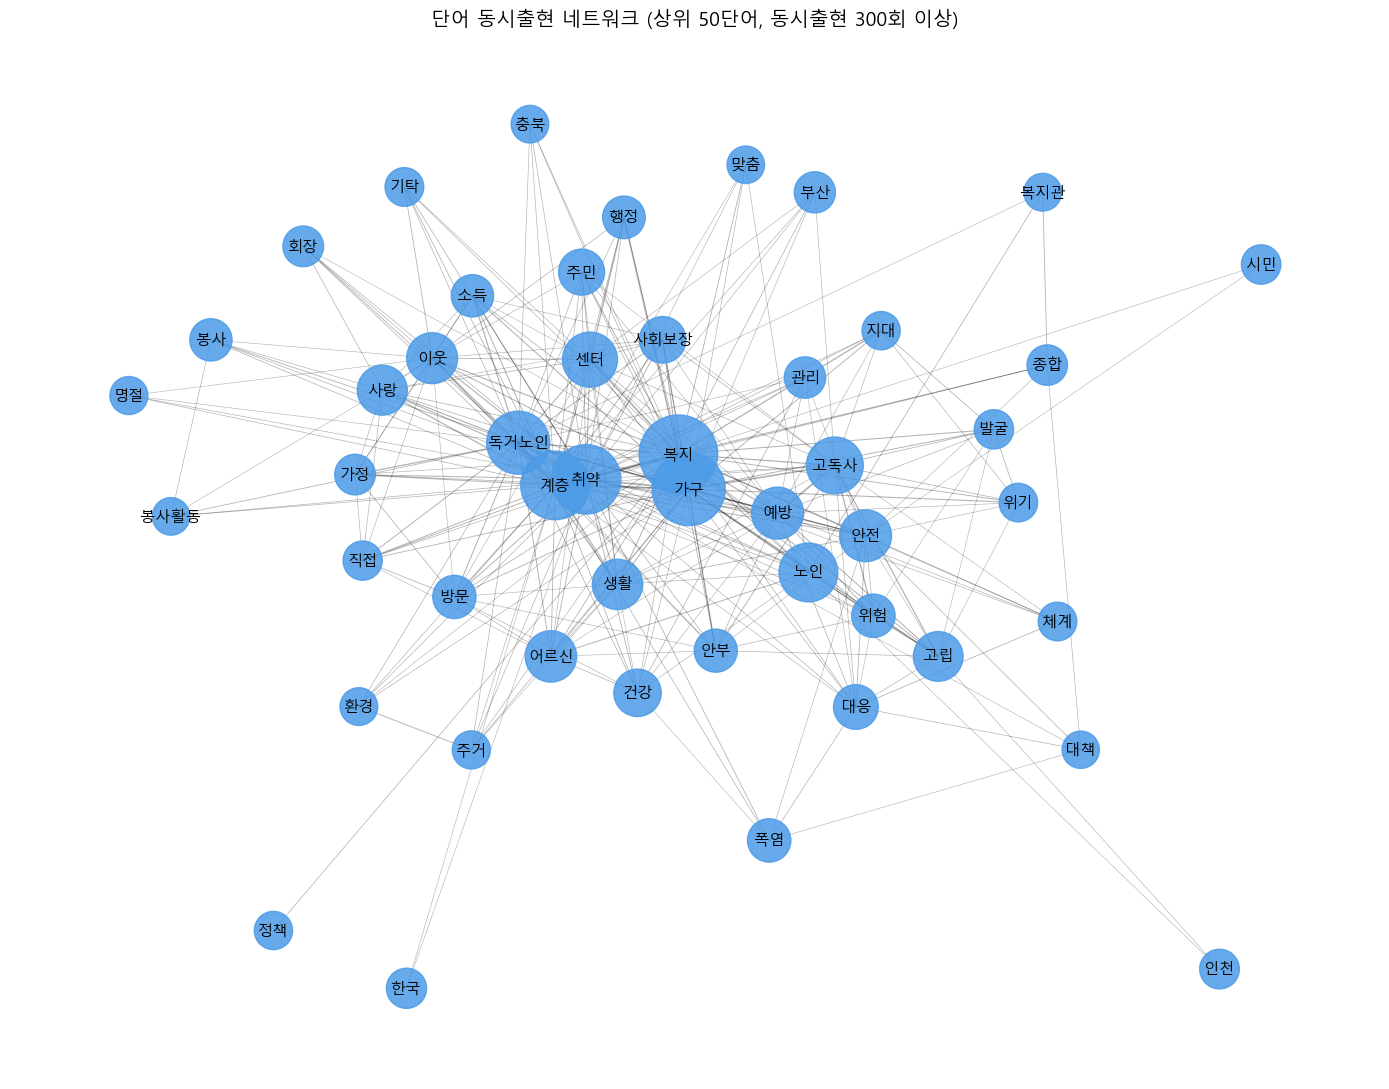

In [4]:
fig, ax = plt.subplots(figsize=(14, 11))
nw.draw_network(G, ax=ax)
ax.set_title("단어 동시출현 네트워크 (상위 50단어, 동시출현 300회 이상)", fontsize=14)
fig.tight_layout()
fig.savefig(config.FIG_DIR / "03_network.png", dpi=150)
plt.show()

## 메모

- 네트워크가 너무 조밀하면(허브가 다 연결되면) `min_cooc`을 올리거나 `top_n`을 줄인다.
- `독거노인·고독사·고립·취약·계층` 등 핵심어가 어떤 단어들과 강하게 엮이는지 보면
  보도 프레임(복지·안전·돌봄·나눔 등)을 읽을 수 있다.